# RQ3.ipynb

In [4]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler


In [5]:

df = pd.read_csv('C:/Users/vrund/Downloads/ML/amazon_sales_2025_INR.csv')
df = df.select_dtypes(include=[np.number]).dropna()
target = df.columns[-1]
X = df.drop(target, axis=1)
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


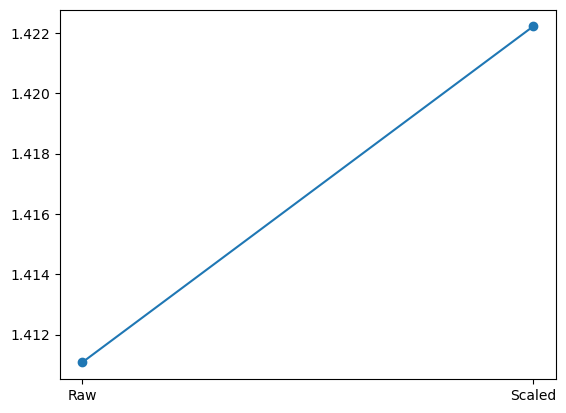

In [7]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

from sklearn.linear_model import LinearRegression
model = LinearRegression()

scores = []

for data in [X, X_scaled]:
    X_tr, X_te, y_tr, y_te = train_test_split(data, y, test_size=0.2)
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    scores.append(np.sqrt(mean_squared_error(y_te,pred)))

df_res = pd.DataFrame({"Stage":["Raw","Scaled"],"RMSE":scores})
df_res.to_csv("RQ3_table.csv", index=False)

plt.figure()
plt.plot(df_res["Stage"], df_res["RMSE"], marker='o')

